<a href="https://colab.research.google.com/github/pontonganronald-byte/pontongan_ai_iris_labactivity1/blob/main/Pontongan_ai_iris_activity1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

print("Libraries successfully imported")


Libraries successfully imported


In [59]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [60]:
iris = load_iris()

In [61]:

print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [62]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [63]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [64]:
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


In [65]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [66]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

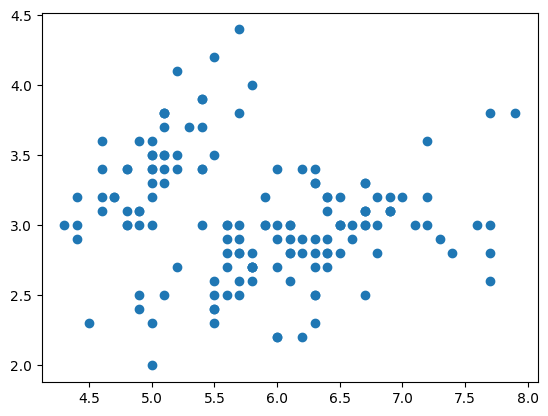

In [67]:
plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"]
)

Text(0.5, 1.0, 'Sepal Length vs Sepal Width')

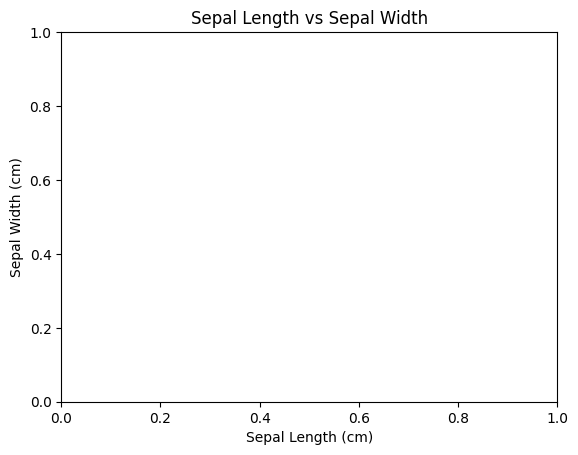

In [68]:
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")

In [69]:
plt.show()

In [70]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [71]:
for species in df["species"].unique():
  subset = df[df["species"]==species]

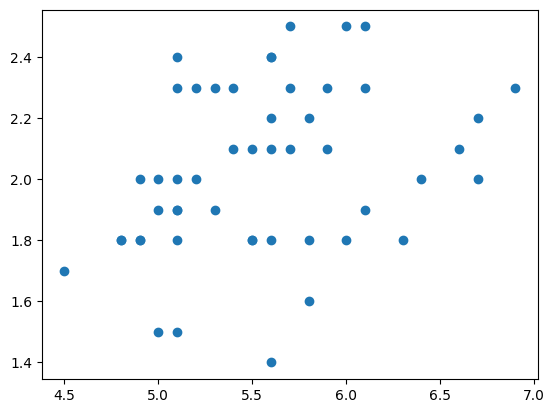

In [72]:
plt.scatter(
      subset["petal length (cm)"],
      subset["petal width (cm)"],
      label = species
  )

/tmp/ipykernel_547/3714271259.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


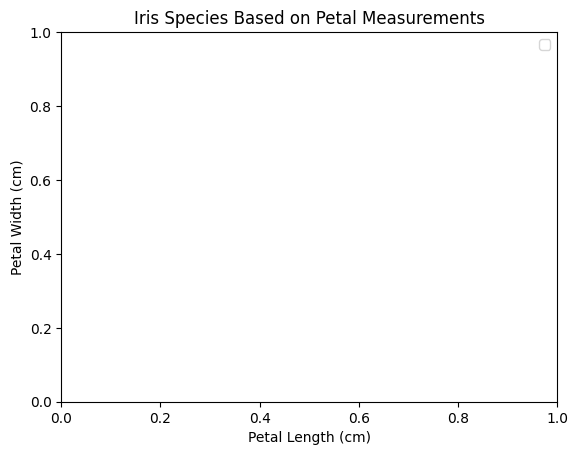

In [73]:
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Species Based on Petal Measurements")
plt.legend()

In [74]:
plt.show()

In [75]:
X = iris.data
y = iris.target

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [77]:
print("Training observations: ", len(X_train))
print("Testing observations: ", len(X_test))

Training observations:  120
Testing observations:  30


In [78]:
model = KNeighborsClassifier(n_neighbors=3)

In [79]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [80]:
y_pred = model.predict(X_test)

In [81]:
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [82]:
print("Actual: ")
print(y_test)

Actual: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [83]:
print("\nPredicted: ")
print(y_pred)


Predicted: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [84]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [85]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

In [86]:
prediction = model.predict(new_flower)

In [87]:
print(
    "Predicted species: ",
    iris.target_names[prediction[0]]
)

Predicted species:  setosa


In [88]:
probabilities = model.predict_proba(new_flower)
print(probabilities)

[[1. 0. 0.]]


In [89]:
for species, probability in zip(
    iris.target_names,
    probabilities[0]
):
    print(f"{species}: {probability:.2%}")

setosa: 100.00%
versicolor: 0.00%
virginica: 0.00%


In [90]:
 print(f"{species}: {probability:2%}")

virginica: 0.000000%


In [91]:
k_values = [1,3,5,7,9]
accuracies = []

In [92]:
for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(f"K={k}, Accuracy={accuracy:2f}")

K=1, Accuracy=0.966667
K=3, Accuracy=1.000000
K=5, Accuracy=1.000000
K=7, Accuracy=0.966667
K=9, Accuracy=1.000000


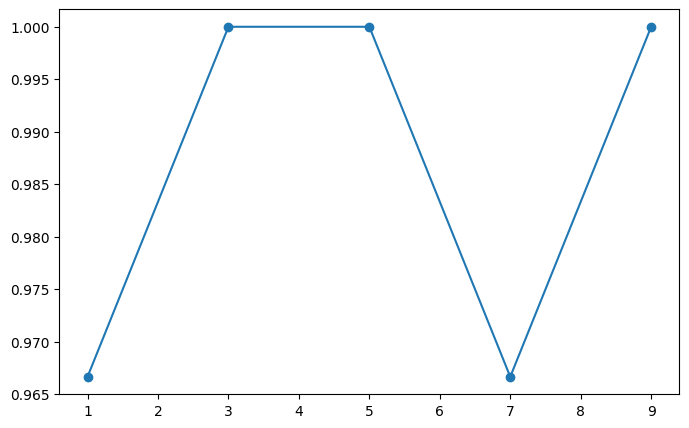

In [93]:
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    accuracies,
    marker="o"
)


Text(0.5, 1.0, 'KNN Model Accuracy for Different K values')

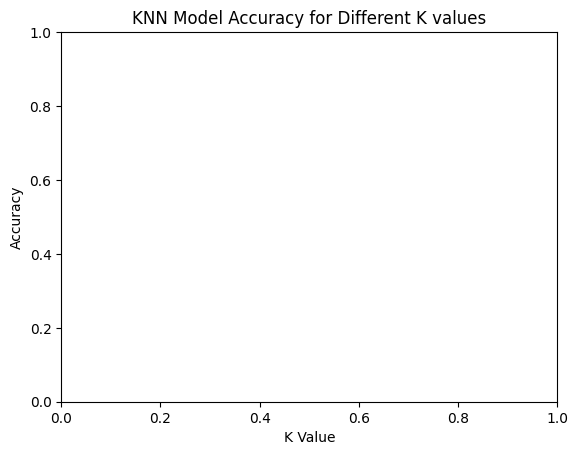

In [94]:
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Model Accuracy for Different K values")

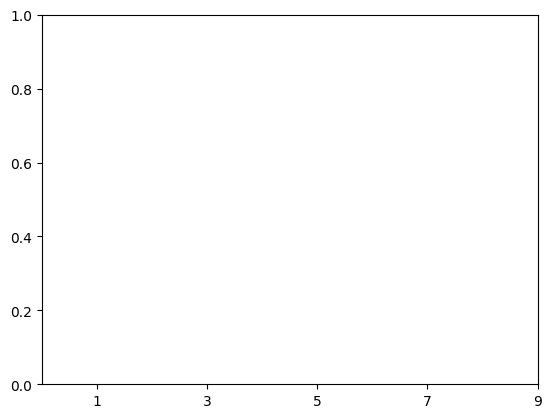

In [95]:
plt.xticks(k_values)
plt.show()

In [96]:
results = pd.DataFrame({
    "Actual":iris.target_names[y_test],
    "Predicted":iris.target_names[y_pred]
})

In [97]:
results.head(10)

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [98]:
results["Correct"] = (
    results["Actual"] == results["Predicted"]
)